In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import * 
from tensorflow.keras.preprocessing import image

In [ ]:
train_datagen = image.ImageDataGenerator(
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1
)
test_datagen= image.ImageDataGenerator(   
    rotation_range=15,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    width_shift_range=0.1,
    height_shift_range=0.1)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/train',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
test_generator = train_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/test',
    target_size = (224,224),
    batch_size = 8,
    class_mode = 'categorical')
validation_generator = test_datagen.flow_from_directory(
    '/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/valid',
    target_size = (224,224),
    batch_size = 8,
    shuffle=True,
    class_mode = 'categorical')

Found 613 images belonging to 4 classes.
Found 315 images belonging to 4 classes.
Found 91 images belonging to 4 classes.


In [ ]:
base_model = tf.keras.applications.VGG19(weights='imagenet', input_shape=(224,224,3), include_top=False)

for layer in base_model.layers:
    layer.trainable=True
model = Sequential()
model.add(base_model)
model.add(GaussianNoise(0.25))
model.add(GlobalAveragePooling2D())
model.add(Dense(1024,activation='relu'))
model.add(BatchNormalization())
model.add(GaussianNoise(0.25))
model.add(Dropout(0.25))
model.add(Dense(4, activation='sigmoid'))
model.summary()

80134624/80134624 [==============================] - 4s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg19 (Functional)          (None, 7, 7, 512)         20024384  
                                                                 
 gaussian_noise (GaussianNoi  (None, 7, 7, 512)        0         
 se)                                                             
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 1024)              525312    
                                                                 
 batch_normalization (BatchN  (None, 1024)             4096      
 ormalization)                                           

In [ ]:
model.compile(loss='categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
              metrics=['accuracy','AUC','Precision','Recall'])

In [ ]:
from keras.callbacks import EarlyStopping
es=EarlyStopping(monitor='val_loss',patience=3)
history = model.fit(
    train_generator,
    epochs=100,
    validation_data=validation_generator,
    steps_per_epoch= 75
    )

Epoch 1/100
75/75 [==============================] - 347s 4s/step - loss: 1.6272 - accuracy: 0.3484 - auc: 0.5810 - precision: 0.2963 - recall: 0.5712 - val_loss: 1.6698 - val_accuracy: 0.4066 - val_auc: 0.6641 - val_precision: 0.2633 - val_recall: 0.9780
Epoch 2/100
75/75 [==============================] - 19s 259ms/step - loss: 1.3228 - accuracy: 0.4355 - auc: 0.6570 - precision: 0.3356 - recall: 0.6633 - val_loss: 2.3538 - val_accuracy: 0.3077 - val_auc: 0.4457 - val_precision: 0.2343 - val_recall: 0.9011
Epoch 3/100
75/75 [==============================] - 16s 212ms/step - loss: 1.3616 - accuracy: 0.3867 - auc: 0.6060 - precision: 0.3042 - recall: 0.5450 - val_loss: 1.4133 - val_accuracy: 0.5055 - val_auc: 0.6389 - val_precision: 0.4821 - val_recall: 0.2967
Epoch 4/100
75/75 [==============================] - 15s 204ms/step - loss: 1.2232 - accuracy: 0.4623 - auc: 0.6750 - precision: 0.3412 - recall: 0.6566 - val_loss: 4.1421 - val_accuracy: 0.2418 - val_auc: 0.3816 - val_precision

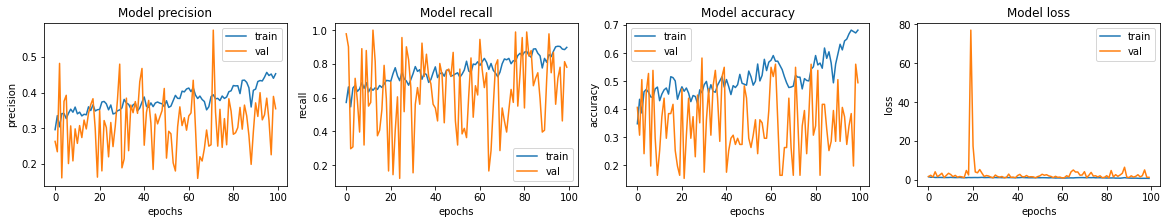

In [ ]:
fig,ax=plt.subplots(1,4,figsize=(20,3))
ax=ax.ravel()
for i,met in enumerate(['precision','recall','accuracy','loss']):
  ax[i].plot(history.history[met])
  ax[i].plot(history.history['val_'+met])
  ax[i].set_title('Model {}'.format(met))
  ax[i].set_xlabel('epochs')
  ax[i].set_ylabel(met)
  ax[i].legend(['train', 'val'])

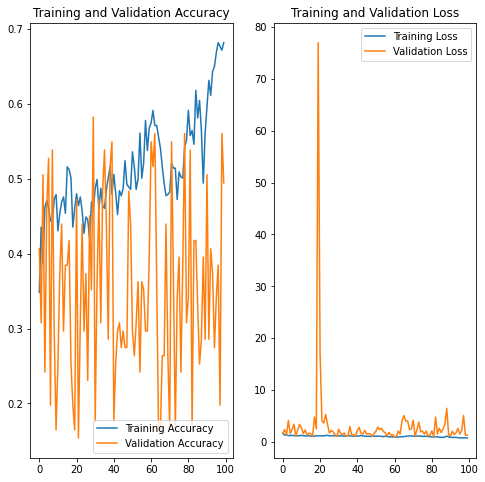

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(100)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

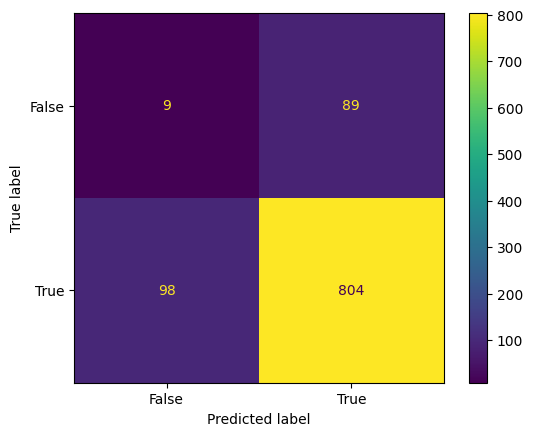

In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

actual = numpy.random.binomial(1,.9,size = 1000)
predicted = numpy.random.binomial(1,.9,size = 1000)

confusion_matrix = metrics.confusion_matrix(actual, predicted)

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [False, True])

cm_display.plot()
plt.show()

In [ ]:
model.evaluate(train_generator)

77/77 [==============================] - 11s 136ms/step - loss: 0.8026 - accuracy: 0.6688 - auc: 0.8699 - precision: 0.4241 - recall: 0.8940


[0.8025810718536377,
 0.6688417792320251,
 0.8698943257331848,
 0.4241486191749573,
 0.8939641118049622]

In [ ]:
model.evaluate(test_generator)

40/40 [==============================] - 225s 6s/step - loss: 1.2117 - accuracy: 0.4952 - auc: 0.7650 - precision: 0.3679 - recall: 0.7651


[1.2116541862487793,
 0.4952380955219269,
 0.7650474309921265,
 0.36793893575668335,
 0.7650793790817261]

In [ ]:
model.evaluate(validation_generator)

12/12 [==============================] - 2s 180ms/step - loss: 1.3617 - accuracy: 0.3956 - auc: 0.7350 - precision: 0.3622 - recall: 0.7802


[1.361678123474121,
 0.3956044018268585,
 0.735015869140625,
 0.3622449040412903,
 0.7802197933197021]

In [ ]:
model.save('/content/drive/MyDrive/Colab Notebooks/Final Project/Original 5 Models/VGG19.h5',model)

In [ ]:
mymodel=load_model('/content/drive/MyDrive/Colab Notebooks/Final Project/Original 5 Models/VGG19.h5')

In [ ]:
mymodel.evaluate(train_generator)

77/77 [==============================] - 11s 142ms/step - loss: 0.8569 - accuracy: 0.6427 - auc: 0.8560 - precision: 0.4191 - recall: 0.8662


[0.8568623065948486,
 0.6427406072616577,
 0.8559761643409729,
 0.41910022497177124,
 0.8662316203117371]

In [ ]:
mymodel.evaluate(test_generator)

40/40 [==============================] - 6s 143ms/step - loss: 1.2418 - accuracy: 0.4921 - auc: 0.7583 - precision: 0.3678 - recall: 0.7683


[1.241764783859253,
 0.4920634925365448,
 0.7582564949989319,
 0.3677811622619629,
 0.7682539820671082]

In [ ]:
mymodel.evaluate(validation_generator)

12/12 [==============================] - 2s 130ms/step - loss: 1.2850 - accuracy: 0.5165 - auc: 0.7632 - precision: 0.3850 - recall: 0.8462


[1.2850193977355957,
 0.5164835453033447,
 0.7631726861000061,
 0.38499999046325684,
 0.8461538553237915]

1/1 [==============================] - 1s 897ms/step
[[0.5365608  0.51767033 0.0043244  0.92249805]]
THE UPLOADED IMAGE IS SUSPECTED AS: squamous cell carcinoma


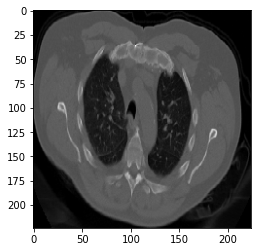

In [ ]:
from keras.preprocessing import image
img = tf.keras.utils.load_img('/content/drive/MyDrive/Colab Notebooks/Final Year Project/Dataset_1/valid/squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa/000117 (4).png',target_size=(224,224))
imag = tf.keras.utils.img_to_array(img)
imaga = np.expand_dims(imag,axis=0) 
ypred = model.predict(imaga)
print(ypred)
a=np.argmax(ypred,-1)
if a==0:
  op="Adenocarcinoma"
elif a==1:
  op="large cell carcinoma"
elif a==2:
  op="normal (void of cancer)"
else:
  op="squamous cell carcinoma"    
plt.imshow(img)
print("THE UPLOADED IMAGE IS SUSPECTED AS: "+str(op))  
